In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
hits = pd.read_pickle('model/data/ga_hits.pkl')
sessions = pd.read_pickle('model/data/ga_sessions.pkl')

In [7]:
print(hits.shape) # Изучаем размер данных
print(sessions.shape)

(15726470, 11)
(1860042, 18)


In [8]:
sessions.info() # Изучаем типы о данных
hits.info()

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB
<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (

In [9]:
sessions.head() # Выводим первые 5 строк sessions

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [10]:
hits.head() # Выводим первые 5 строк hits

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,None
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,None
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,None
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,None
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,None


In [11]:
sessions.isna().sum().sort_values(ascending=False).head(20) #Изучаем пропуски в sessions

device_model                1843704
utm_keyword                 1082061
device_os                   1070138
utm_adcontent                335615
utm_campaign                 219603
device_brand                 118678
utm_source                       97
session_id                        0
client_id                         0
visit_number                      0
utm_medium                        0
visit_date                        0
visit_time                        0
device_category                   0
device_screen_resolution          0
device_browser                    0
geo_country                       0
geo_city                          0
dtype: int64

In [12]:
sessions = sessions.drop(columns = ['device_model']) # Удаляем колонку device_model, так как в ней более 90% пропусков.

In [13]:
cols = [
    'utm_keyword',
    'device_os',
    'utm_adcontent',
    'utm_campaign',
    'device_brand',
    'utm_source'
]

for col in cols:
    sessions[col] = sessions[col].fillna('unknown')

# Заменяем пропущенные значения на unknown

In [14]:
hits.isna().sum().sort_values(ascending=False).head(20) #Изучаем пропуски в hits

event_value       15726470
hit_time           9160322
hit_referer        6274804
event_label        3760184
session_id               0
hit_date                 0
hit_number               0
hit_page_path            0
hit_type                 0
event_action             0
event_category           0
dtype: int64

In [15]:
hits = hits.drop(columns = ['event_value']) # Удаляем колонку event_value, так как в ней более 90% пропусков.

In [16]:
sessions.duplicated().sum() # Смотрим количество дубликатов в sessions

np.int64(0)

In [17]:
hits.duplicated().sum() # Смотрим количество дубликатов в hits

np.int64(0)

In [18]:
target_events = [
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sun_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
]
# Создаем target с целевыми действиями

In [19]:
target_sessions = hits[hits['event_action'].isin(target_events)]['session_id'].unique() # Получаем список сессий, где было целевое действие

In [20]:
print(len(target_sessions))

39413


In [21]:
sessions['target'] = sessions['session_id'].isin(target_sessions).astype(int) # Создаем колонку в sessions

In [22]:
sessions['target'].value_counts() # Проверяем распределение

target
0    1821012
1      39030
Name: count, dtype: int64

In [23]:
sessions['target'].value_counts(normalize=True)

target
0    0.979017
1    0.020983
Name: proportion, dtype: float64

Целевое действие совершили около 2.1% пользователей. Датасет является сильно несбалансированным, поэтому в качестве основной метрики качества модели будет использоваться ROC-AUC вместо Accuracy.

In [24]:
sessions = sessions.drop(
    columns = [
        'session_id',
        'client_id'
    ]
)

In [25]:
sessions['visit_date'] = pd.to_datetime(sessions['visit_date']) # Обработаем даты

In [26]:
sessions['visit_month'] = sessions['visit_date'].dt.month

In [27]:
sessions['visit_day'] = sessions['visit_date'].dt.day

In [28]:
sessions['visit_weekday'] = sessions['visit_date'].dt.weekday

In [29]:
sessions = sessions.drop(columns = ['visit_date']) # Удаляем столбец visit_date

In [30]:
sessions.nunique().sort_values(ascending=False)

visit_time                  85318
device_screen_resolution     5039
geo_city                     2548
utm_keyword                  1220
visit_number                  537
utm_campaign                  413
utm_source                    294
utm_adcontent                 287
device_brand                  207
geo_country                   166
device_browser                 57
utm_medium                     56
visit_day                      31
device_os                      14
visit_month                     8
visit_weekday                   7
device_category                 3
target                          2
dtype: int64

<Axes: xlabel='device_category'>

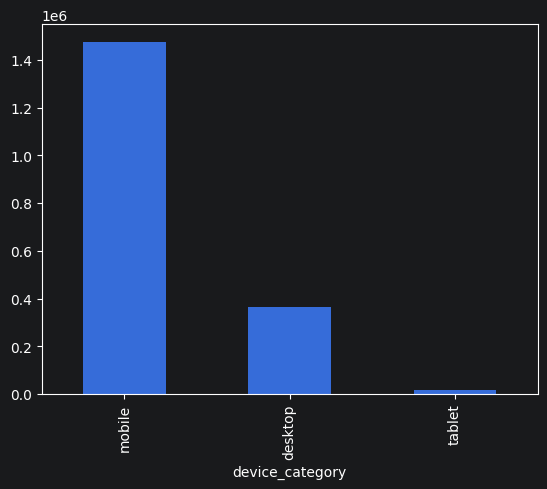

In [31]:
sessions['device_category'].value_counts().plot(kind='bar')

<Axes: xlabel='geo_city'>

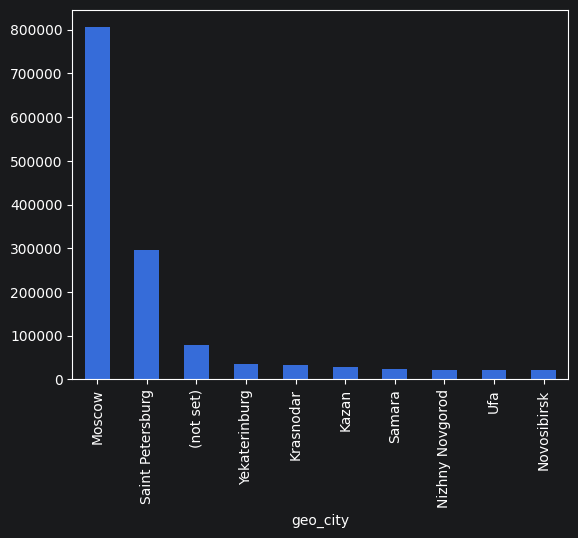

In [32]:
sessions['geo_city'].value_counts().head(10).plot(kind='bar')

<Axes: >

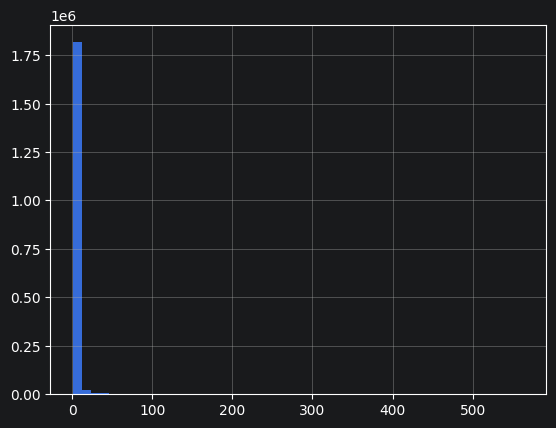

In [33]:
sessions['visit_number'].hist(bins=50)

<Axes: xlabel='device_browser'>

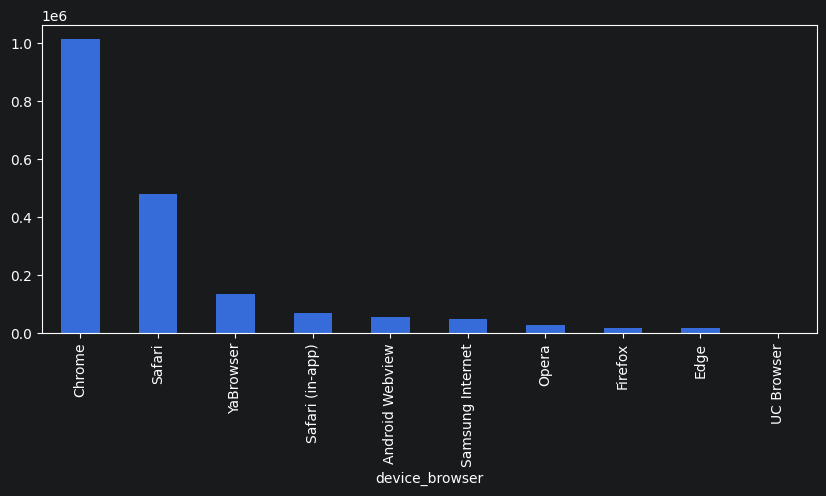

In [34]:
sessions['device_browser'].value_counts().head(10).plot(kind='bar', figsize=(10,4))

<Axes: xlabel='utm_medium'>

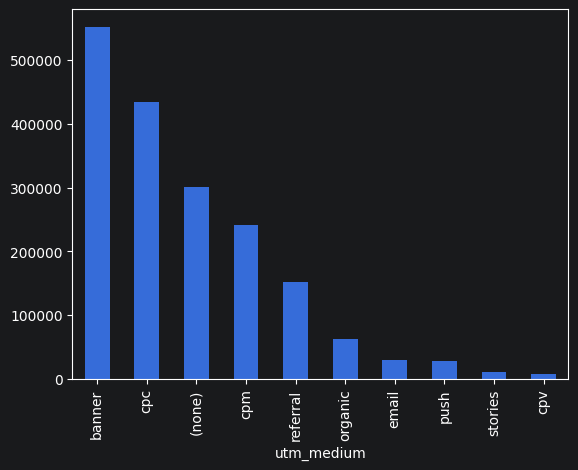

In [35]:
sessions['utm_medium'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='target'>

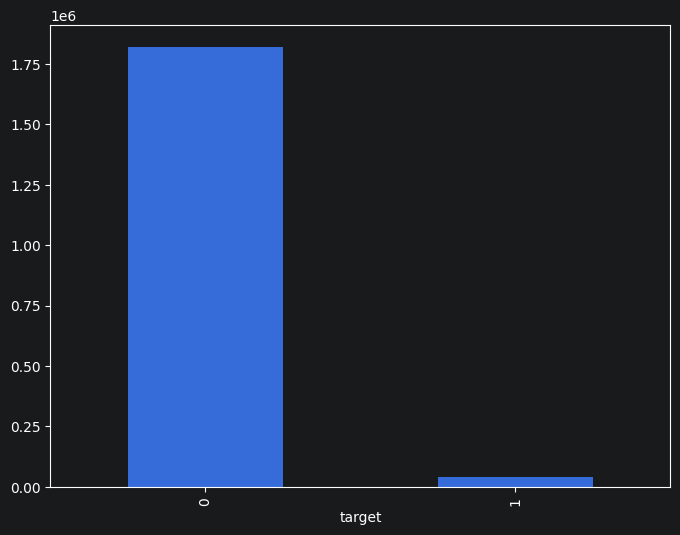

In [36]:
sessions['target'].value_counts().plot(kind='bar', figsize=(8,6))

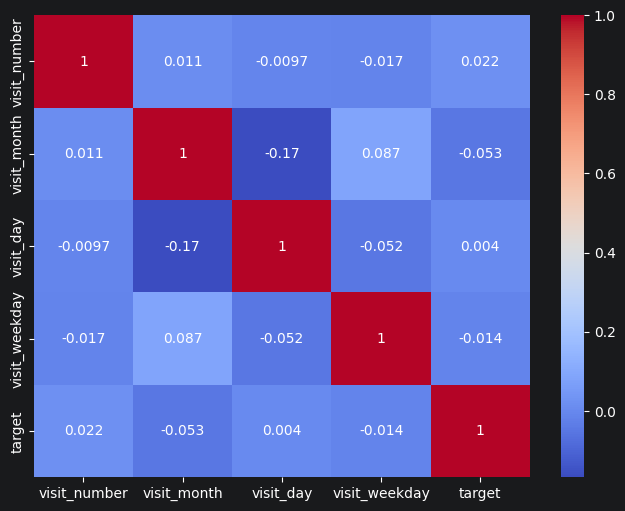

In [37]:
corr = sessions[
    ['visit_number',
     'visit_month',
     'visit_day',
     'visit_weekday',
     'target']
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Выполняет корреляцию

Между числовыми признаками отсутствуют сильные линейные зависимости. Максимальная по модулю корреляция наблюдается между visit_month и visit_day (-0.17), что является слабой связью. Целевая переменная target практически не имеет линейной корреляции с числовыми признаками, что говорит о том, что основную информацию для предсказания, вероятно, несут категориальные признаки (utm_*, device_*, geo_*).

In [38]:
sessions.to_pickle('sessions_eda.pkl')